In [10]:
# importing some labriries 
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")


In [11]:
!pip install xlrd


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
path = r"C:\Users\Admin\Desktop\datasets\Concrete_Data.xls"

df = pd.read_excel(path, engine="xlrd")

df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [13]:
#shows dataset information
print(df.shape)
df.info()
df.describe()
#checking missing values and duplicate rows
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()


(1030, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)   

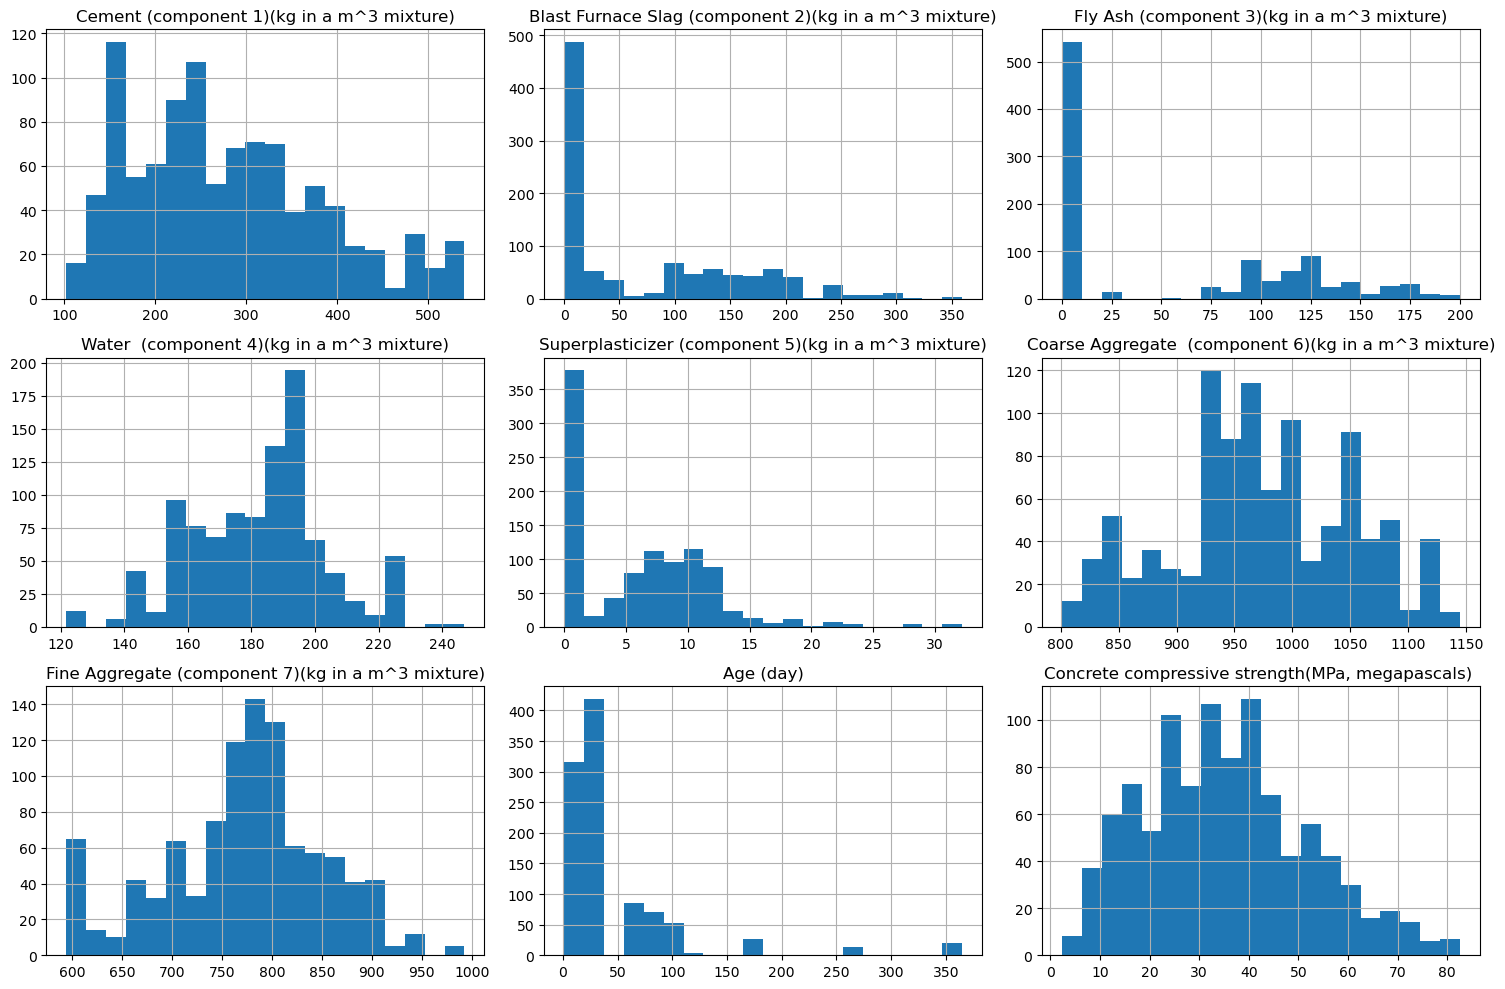

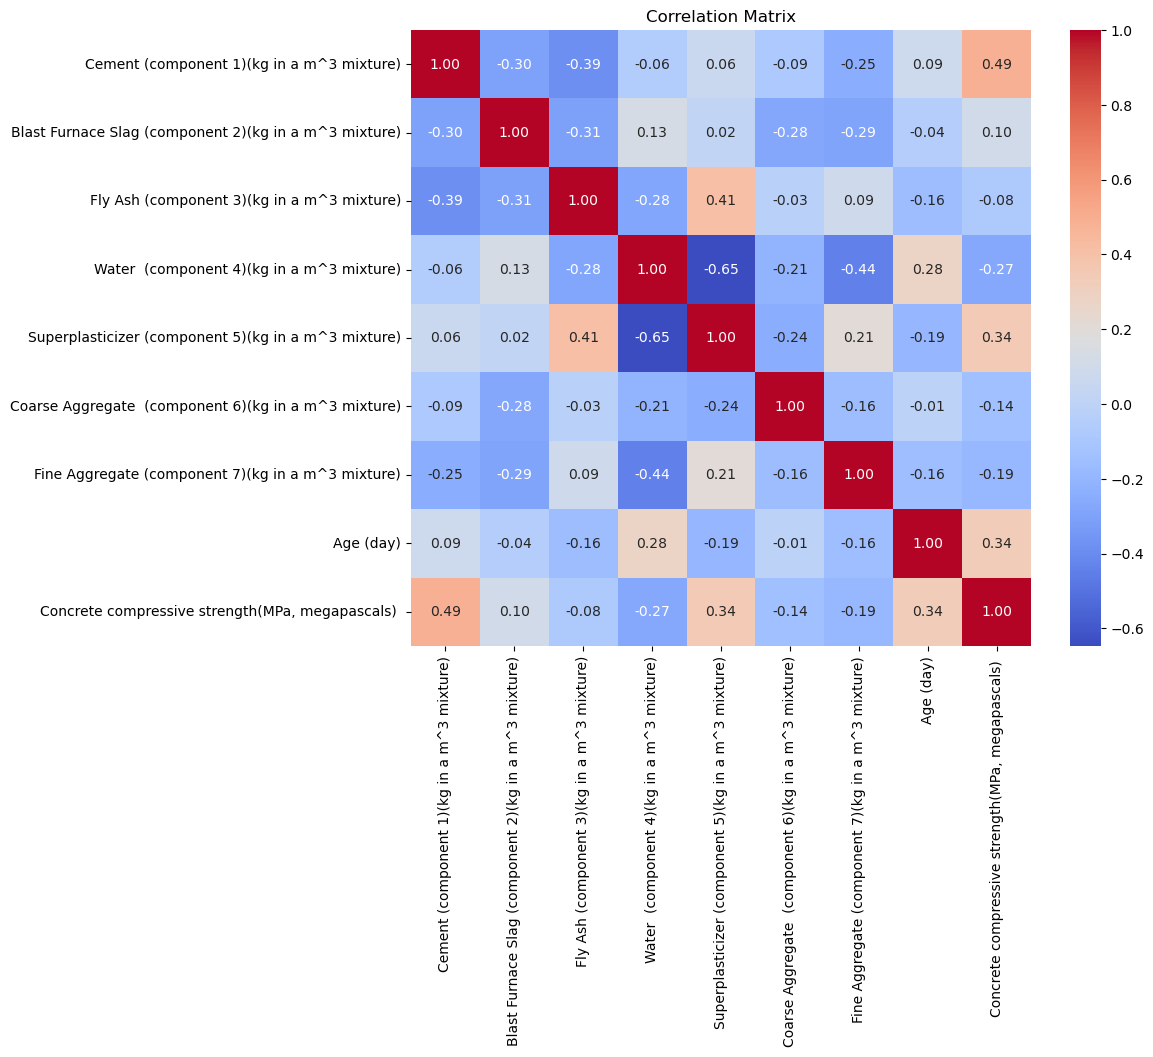

In [14]:
import seaborn as sns
#shows distribution of features
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()
# correlation matrix
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

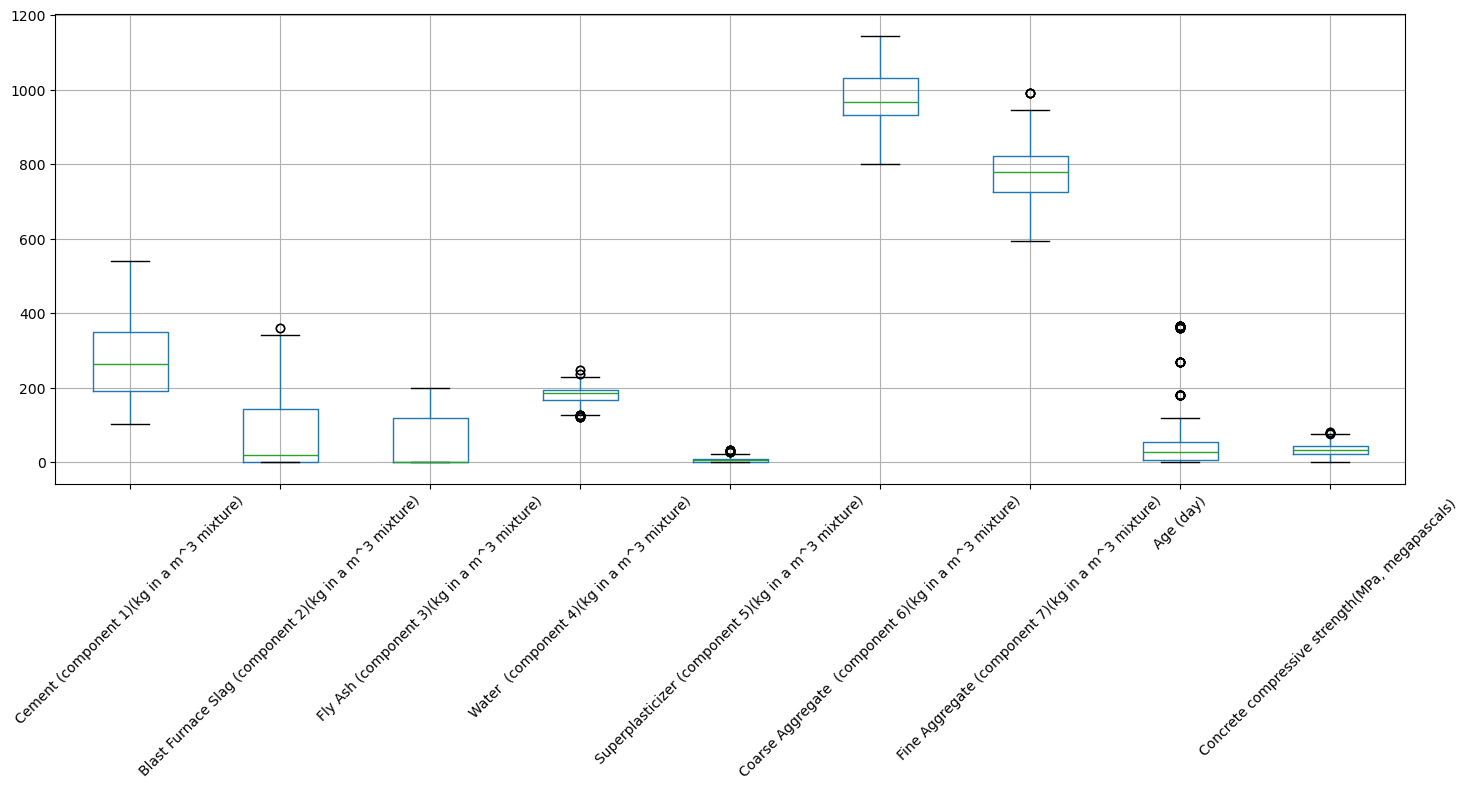

In [15]:
# 0utlier detection
plt.figure(figsize=(15,8))
df.boxplot(rot=45)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
# feature target and selection
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
# train $ test splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Shape of the training set: ",X_train.shape)
print("Shape of the testing set: ",X_test.shape)
# feature scalling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Shape of the training set:  (804, 8)
Shape of the testing set:  (201, 8)


In [39]:
from sklearn.linear_model import Ridge
import numpy as np

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

print("Ridge (alpha = 1)")
print(f"Training R²: {ridge.score(X_train_scaled, y_train):.3f}")
print(f"Testing R² : {ridge.score(X_test_scaled, y_test):.3f}")
print("Number of features used:", np.sum(ridge.coef_ != 0))

Ridge (alpha = 1)
Training R²: 0.610
Testing R² : 0.580
Number of features used: 8


In [40]:
alphas = [0.01, 0.1, 1, 10, 100]
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)

    print(f"alpha={alpha:<6} Train={train_score:.3f} Test={test_score:.3f}")

alpha=0.01   Train=0.610 Test=0.580
alpha=0.1    Train=0.610 Test=0.580
alpha=1      Train=0.610 Test=0.580
alpha=10     Train=0.608 Test=0.577
alpha=100    Train=0.588 Test=0.550


In [44]:
ridge001 = Ridge(alpha=0.001).fit(X_train_scaled, y_train)
ridge01 = Ridge(alpha=0.1).fit(X_train_scaled, y_train)
ridge1 = Ridge(alpha=1).fit(X_train_scaled, y_train)
ridge10 = Ridge(alpha=10).fit(X_train_scaled, y_train)
ridge100 = Ridge(alpha=100).fit(X_train_scaled, y_train)

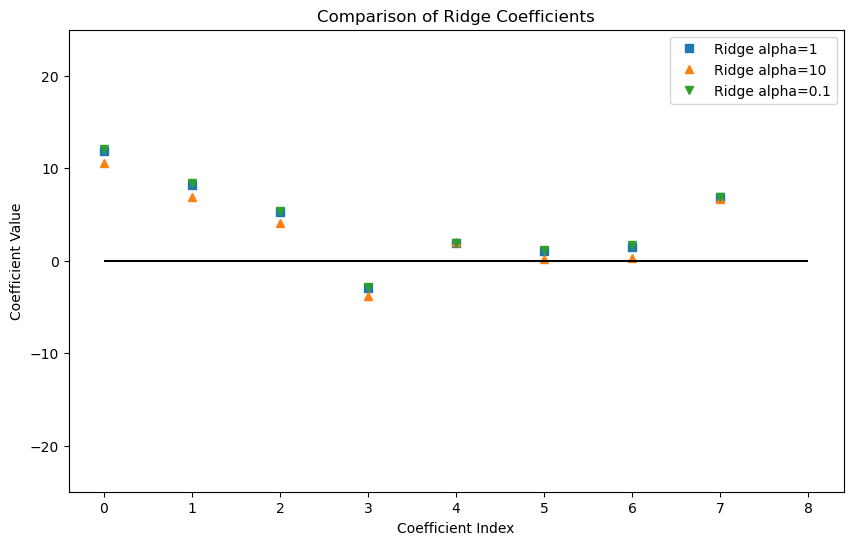

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(ridge.coef_, 's', label='Ridge alpha=1')
plt.plot(ridge10.coef_, '^', label='Ridge alpha=10')
plt.plot(ridge01.coef_, 'v', label='Ridge alpha=0.1')

plt.ylim(-25, 25)

plt.hlines(0, 0, len(ridge.coef_), color='black')

plt.xlabel("Coefficient Index")
plt.ylabel("Coefficient Value")
plt.title("Comparison of Ridge Coefficients")

plt.legend()
plt.show()

In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2'
)
grid.fit(X_train_scaled, y_train)

print("Best alpha:", grid.best_params_['alpha'])
print("Best cross-validation R²:", round(grid.best_score_, 3))

Best alpha: 1
Best cross-validation R²: 0.593


In [85]:
#ridge evaluation and comparison
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
ridge_pred = ridge.predict(X_test_scaled)

print("R²:", r2_score(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("MAE:", mean_absolute_error(y_test, ridge_pred))

R²: -5420.8800941627605
RMSE: 36.80531569416189
MAE: 34.77060534665036


In [54]:
from sklearn.linear_model import Lasso
import numpy as np

#create model
# Create the model
lasso = Lasso().fit(X_train_scaled, y_train)

# Check model accuracy
print(f"Accuracy of the training set: {lasso.score(X_train_scaled, y_train):.3f}")
print(f"Accuracy of the testing set: {lasso.score(X_test_scaled, y_test):.3f}")

print("Number of features used:", np.sum(lasso.coef_ != 0))


Accuracy of the training set: 0.558
Accuracy of the testing set: 0.513
Number of features used: 7


In [55]:
lasso001 = Lasso(alpha=0.01).fit(X_train_scaled, y_train)

print(f"Accuracy of the training set: {lasso001.score(X_train_scaled, y_train):.3f}")
print(f"Accuracy of the testing set: {lasso001.score(X_test_scaled, y_test):.3f}")

print("Number of features used:", np.sum(lasso001.coef_ != 0))

Accuracy of the training set: 0.610
Accuracy of the testing set: 0.580
Number of features used: 8


In [56]:
lasso01 = Lasso(alpha=0.1).fit(X_train_scaled, y_train)

print(f"Accuracy of the training set: {lasso01.score(X_train_scaled, y_train):.3f}")
print(f"Accuracy of the testing set: {lasso01.score(X_test_scaled, y_test):.3f}")

print("Number of features used:", np.sum(lasso01.coef_ != 0))

Accuracy of the training set: 0.608
Accuracy of the testing set: 0.577
Number of features used: 6


In [57]:
lasso10 = Lasso(alpha=10).fit(X_train_scaled, y_train)

print(f"Accuracy of the training set: {lasso10.score(X_train_scaled, y_train):.3f}")
print(f"Accuracy of the testing set: {lasso10.score(X_test_scaled, y_test):.3f}")

print("Number of features used:", np.sum(lasso10.coef_ != 0))

Accuracy of the training set: 0.000
Accuracy of the testing set: -0.003
Number of features used: 0


In [58]:
alphas = [0.001, 0.01, 0.1, 1, 10]

print("Alpha\tTraining\tTesting\tFeatures")

for alpha in alphas:
    model = Lasso(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    print(f"{alpha:<6} "
          f"{model.score(X_train_scaled, y_train):.3f}\t"
          f"{model.score(X_test_scaled, y_test):.3f}\t"
          f"{np.sum(model.coef_ != 0)}")

Alpha	Training	Testing	Features
0.001  0.610	0.580	8
0.01   0.610	0.580	8
0.1    0.608	0.577	6
1      0.558	0.513	7
10     0.000	-0.003	0


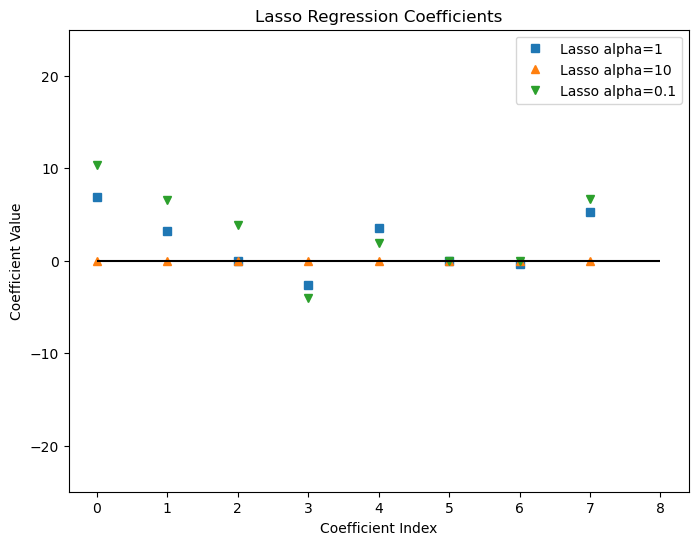

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(lasso.coef_, 's', label='Lasso alpha=1')
plt.plot(lasso10.coef_, '^', label='Lasso alpha=10')
plt.plot(lasso01.coef_, 'v', label='Lasso alpha=0.1')

plt.ylim(-25,25)

plt.hlines(0, 0, len(lasso.coef_), color='black')

plt.xlabel("Coefficient Index")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients")

plt.legend()

plt.show()

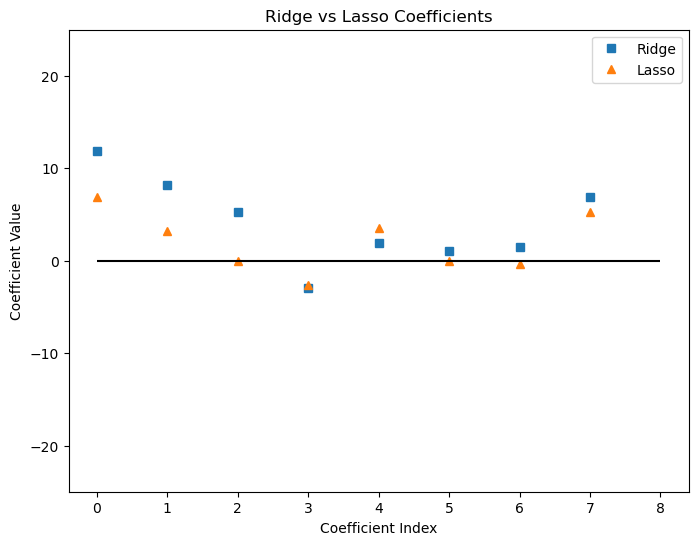

In [60]:
plt.figure(figsize=(8,6))

plt.plot(ridge.coef_, 's', label='Ridge')
plt.plot(lasso.coef_, '^', label='Lasso')

plt.ylim(-25,25)

plt.hlines(0, 0, len(ridge.coef_), color='black')

plt.xlabel("Coefficient Index")
plt.ylabel("Coefficient Value")
plt.title("Ridge vs Lasso Coefficients")

plt.legend()

plt.show()

In [86]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
lasso_pred = lasso.predict(X_test_scaled)

print("R²:", r2_score(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("MAE:", mean_absolute_error(y_test, lasso_pred))

R²: -5215.568018006077
RMSE: 36.101731342272075
MAE: 34.81119962477049


In [87]:
#logistic regression
# Create a binary target using the median strength
threshold = df.iloc[:, -1].median()
df["Strength_Class"] = np.where(df.iloc[:, -1] >= threshold, 1, 0)
df.head()
# Features
X = df.iloc[:, :-2]
# Classification target
y = df["Strength_Class"]

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [89]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(max_iter=100000)

logistic.fit(X_train_scaled, y_train)

print(f"Training Accuracy: {logistic.score(X_train_scaled, y_train):.3f}")
print(f"Testing Accuracy : {logistic.score(X_test_scaled, y_test):.3f}")

Training Accuracy: 0.850
Testing Accuracy : 0.861


In [90]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = logistic.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        98
           1       0.88      0.84      0.86       103

    accuracy                           0.86       201
   macro avg       0.86      0.86      0.86       201
weighted avg       0.86      0.86      0.86       201



In [91]:
logistic100=LogisticRegression(C=100,max_iter=100000).fit(X_train,y_train)
#test for the accuracy
print(f"Training test set accuracy: {logistic100.score(X_train,y_train):.2f}")
print(f"Testing test set accuracy: {logistic100.score(X_test,y_test):.2f}")

Training test set accuracy: 0.85
Testing test set accuracy: 0.86


In [92]:
logistic001=LogisticRegression(C=0.001,max_iter=100000).fit(X_train,y_train)
#test for the accuracy
print(f"Training test set accuracy: {logistic001.score(X_train,y_train):.2f}")
print(f"Testing test set accuracy: {logistic001.score(X_test,y_test):.2f}")

Training test set accuracy: 0.84
Testing test set accuracy: 0.87


In [93]:
#coefficient Values
print("Coefficients values of the model: ",logistic.coef_)
print("Intercept value of the model: ",logistic.intercept_)

Coefficients values of the model:  [[ 1.6621471   0.85918052  0.47292547 -0.62319984  0.59154202  0.0404146
  -0.33827164  2.56089865]]
Intercept value of the model:  [0.42222439]


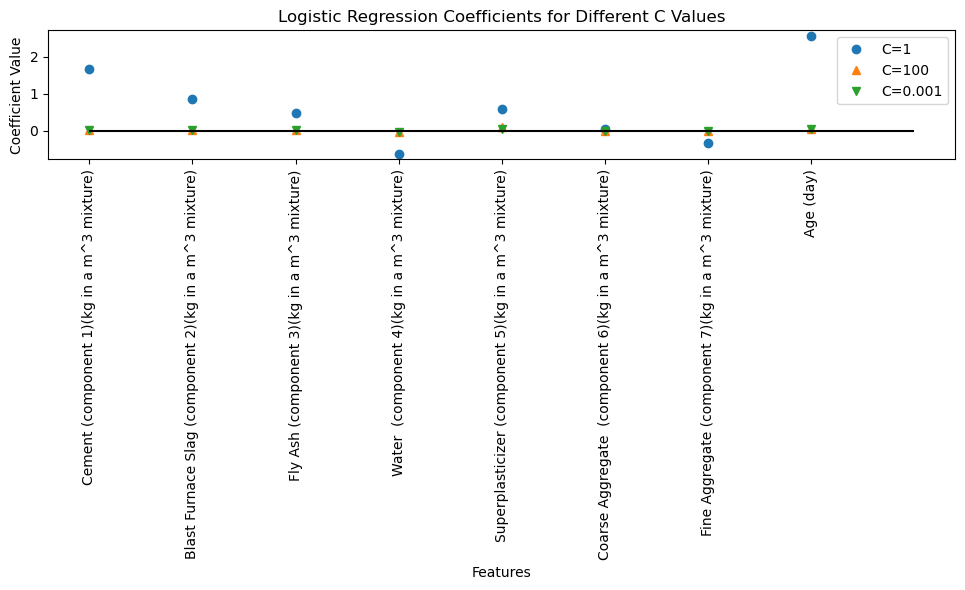

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(logistic.coef_.T, 'o', label='C=1')
plt.plot(logistic100.coef_.T, '^', label='C=100')
plt.plot(logistic001.coef_.T, 'v', label='C=0.001')

# Use your dataset's feature names
plt.xticks(range(X.shape[1]), X.columns, rotation=90)

plt.hlines(0, 0, X.shape[1], color='black')

plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Logistic Regression Coefficients for Different C Values")

plt.legend()

plt.tight_layout()
plt.show()

In [95]:
from sklearn.svm import LinearSVC
# Create the model
linear_svc = LinearSVC(C=1, max_iter=100000)
# Train the model
linear_svc.fit(X_train_scaled, y_train)
# Check model accuracy
print(f"Training Accuracy: {linear_svc.score(X_train_scaled, y_train):.3f}")
print(f"Testing Accuracy : {linear_svc.score(X_test_scaled, y_test):.3f}")

Training Accuracy: 0.838
Testing Accuracy : 0.861


In [96]:
# checking for c=100
linear_svc100 = LinearSVC(C=100, max_iter=100000)
linear_svc100.fit(X_train_scaled, y_train)

print(f"Training Accuracy: {linear_svc100.score(X_train_scaled, y_train):.3f}")
print(f"Testing Accuracy : {linear_svc100.score(X_test_scaled, y_test):.3f}")

Training Accuracy: 0.836
Testing Accuracy : 0.861


In [97]:
# checking for c=0.001
from sklearn.svm import LinearSVC
linear_svc001 = LinearSVC(C=0.01, max_iter=100000)
linear_svc001.fit(X_train_scaled, y_train)

print(f"Training Accuracy: {linear_svc001.score(X_train_scaled, y_train):.3f}")
print(f"Testing Accuracy : {linear_svc001.score(X_test_scaled, y_test):.3f}")

Training Accuracy: 0.826
Testing Accuracy : 0.851


In [98]:
#comparing different c values 
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

print("C\tTraining\tTesting")

for c in C_values:

    model = LinearSVC(C=c, max_iter=100000)

    model.fit(X_train_scaled, y_train)

    train_score = model.score(X_train_scaled, y_train)

    test_score = model.score(X_test_scaled, y_test)

    print(f"{c:<6} {train_score:.3f}\t\t{test_score:.3f}")

C	Training	Testing
0.001  0.812		0.826
0.01   0.826		0.851
0.1    0.837		0.861
1      0.838		0.861
10     0.837		0.861
100    0.836		0.861


In [99]:
#classification report
from sklearn.metrics import classification_report
y_pred = linear_svc.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86        98
           1       0.89      0.83      0.86       103

    accuracy                           0.86       201
   macro avg       0.86      0.86      0.86       201
weighted avg       0.86      0.86      0.86       201



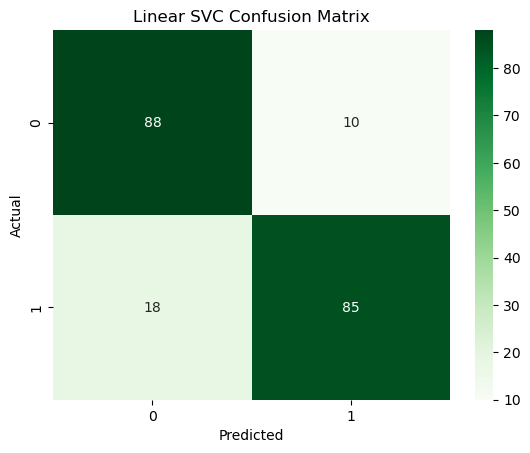

In [100]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVC Confusion Matrix")

plt.show()

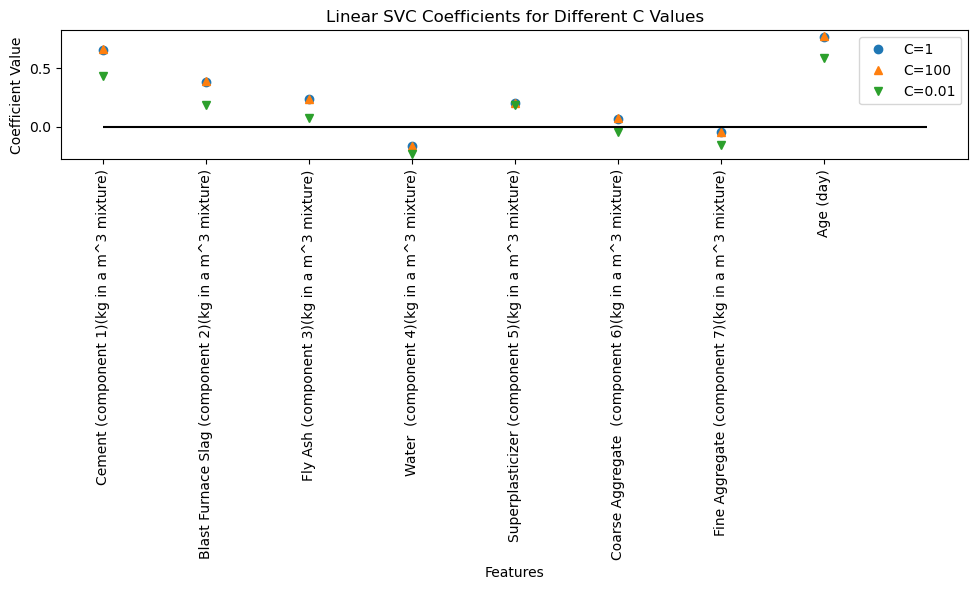

In [101]:
#plotting different coefficient
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(linear_svc.coef_.T, 'o', label='C=1')
plt.plot(linear_svc100.coef_.T, '^', label='C=100')
plt.plot(linear_svc001.coef_.T, 'v', label='C=0.01')

plt.xticks(range(X.shape[1]), X.columns, rotation=90)

plt.hlines(0, 0, X.shape[1], color='black')

plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Linear SVC Coefficients for Different C Values")

plt.legend()

plt.tight_layout()

plt.show()

In [102]:
# perfomance improvement
from sklearn.model_selection import GridSearchCV
parameters = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LinearSVC(max_iter=100000),
    parameters,
    cv=5
)

grid.fit(X_train_scaled, y_train)

print("Best C:", grid.best_params_['C'])
print("Best Cross-Validation Accuracy:", grid.best_score_)

Best C: 0.1
Best Cross-Validation Accuracy: 0.8308462732919255
